In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import time

In [2]:
class RandomDataset(Dataset):
    def __init__(self, num_samples: int):
        self.img = torch.randn(num_samples, 1, 512, 512)
        self.scalar = torch.randn(num_samples, 1)
        self.label = torch.randn(num_samples, 1)

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image = self.img[idx]
        scalar = self.scalar[idx]
        label = self.label[idx]
        return image, scalar, label

dataset = RandomDataset(1000)
dataloader = DataLoader(dataset , batch_size=1, shuffle=False, num_workers=1)

In [3]:
from pynq import get_rails, DataRecorder

rails = get_rails()
recorder = DataRecorder(rails['INT'].power)

# Test CPU

In [4]:
from CNetPlusScalar import CNetPlusScalar
model = CNetPlusScalar()
#model.load_state_dict(torch.load('pre_trained_w.pt'))

In [5]:
recorder.record(0.001)

In [6]:
model.eval()
with torch.no_grad():
    inference_time = 0
    cpu_output = []
    recorder.mark()
    for image, scalar, _ in dataloader:
        # Run inference for each image individually
        pred = model(image, scalar)
    recorder.mark()

# Test DPU

In [7]:
from pynq_dpu import DpuOverlay
overlay = DpuOverlay("../vitisai_bitstream/dpu.bit")

In [8]:
overlay.load_model("zcu104_CNetPlusScalar.xmodel")

In [9]:
dpu = overlay.runner

inputTensors = dpu.get_input_tensors()
outputTensors = dpu.get_output_tensors()

shapeIn_img = tuple(inputTensors[0].dims)
shapeIn_scalar = tuple(inputTensors[1].dims)
shapeOut = tuple(outputTensors[0].dims)
outputSize = int(outputTensors[0].get_data_size() / shapeIn_img[0])

output_data = [np.empty(shapeOut, dtype=np.float32, order="C")]
input_data = [np.empty(shapeIn_img, dtype=np.float32, order="C"), np.empty(shapeIn_scalar, dtype=np.float32, order="C")]
data_img = input_data[0]
data_scalar = input_data[1]

In [10]:
inference_time = 0
vitisAI_output = []
recorder.mark()
for image, data_scalar, _ in dataloader:
    data = image.permute(0,2,3,1)
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)
recorder.mark()

4

In [11]:
recorder.stop()

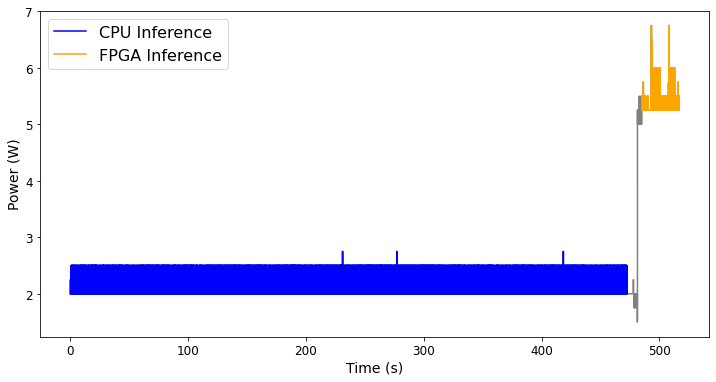

In [12]:
import matplotlib.pyplot as plt

# Get the timestamps of the marks
mark_indices = []
last_mark = 0.0
for i, mark in enumerate(recorder.frame['Mark']):
    if mark > last_mark:
        mark_indices.append(i)
        last_mark = mark

# Extract the power data
power_data = recorder.frame['INT_power']
time_data = recorder.frame.index
elapsed_time = (time_data - time_data[0]).total_seconds()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(elapsed_time, power_data, color='gray')

# Color the plot based on the marks
plt.plot(elapsed_time[mark_indices[0]:mark_indices[1]], power_data[mark_indices[0]:mark_indices[1]], color='blue', label='CPU Inference')
plt.plot(elapsed_time[mark_indices[2]:mark_indices[3]], power_data[mark_indices[2]:mark_indices[3]], color='orange', label='FPGA Inference')

# Add labels and title with larger font size
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Power (W)', fontsize=14)
#plt.title('Power Consumption of CPU and FPGA Inference for MMS Neural Networks', fontsize=12)

# Add legend with larger font size
plt.legend(fontsize=16)

# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.savefig("power_consumption.pdf")
plt.show()

In [13]:
max_power = max(power_data[mark_indices[0]:mark_indices[1]])
print(f"CPU maximum power consumption during execution: {max_power} W")
max_power = max(power_data[mark_indices[2]:mark_indices[3]])
print(f"FPGA maximum power consumption during execution: {max_power} W")

CPU maximum power consumption during execution: 2.75 W
FPGA maximum power consumption during execution: 6.75 W


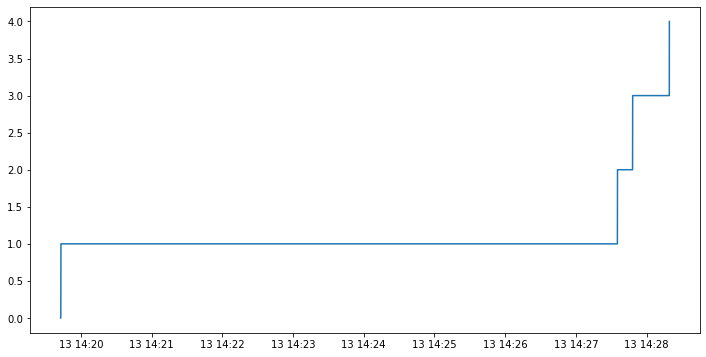

In [14]:
# Extract the power data
mark_data = recorder.frame['Mark']
time_data = recorder.frame.index

# Create the plot
plt.figure(figsize=(12, 6))

# Color the plot based on the marks
plt.plot(time_data, mark_data)

# Show the plot
plt.show()